In [1]:
pip install transformers torch pandas

Note: you may need to restart the kernel to use updated packages.


In [42]:
import pandas as pd
import pandas as pd
from transformers import pipeline
import torch

pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)


In [3]:
ROOT_DIR = "/home/gabriella/Documents/MemorabilityEmotions"

In [43]:

df = pd.read_parquet(f"{ROOT_DIR}/lamem_features_v3/lamem_features_v2_full.parquet", engine="fastparquet")
print(df.head())

              name   dataset  memscore original_emotion  error  \
0   original/2.jpg  abnormal  0.694118                   False   
1   original/4.jpg       art  0.792208        amusement  False   
2  original/30.jpg  abnormal  0.848101                   False   
3  original/53.jpg       art  0.764706       excitement  False   
4  original/59.jpg       art  0.758242              awe  False   

   emotion_happiness  emotion_sadness  emotion_fear  emotion_anger  \
0           0.165649         0.167725      0.165283       0.167358   
1           0.164673         0.166748      0.166016       0.169067   
2           0.165039         0.167480      0.167114       0.171387   
3           0.169678         0.165527      0.166138       0.166992   
4           0.164917         0.170410      0.165771       0.168213   

   emotion_disgust  emotion_surprise clip_emotion  clip_emotion_conf  \
0         0.166138          0.167725      sadness           0.167725   
1         0.166382          0.167114  

In [44]:
df

,name,dataset,memscore,original_emotion,error,emotion_happiness,emotion_sadness,emotion_fear,emotion_anger,emotion_disgust,emotion_surprise,clip_emotion,clip_emotion_conf,caption
0,original/2.jpg,abnormal,0.694118,,False,0.165649,0.167725,0.165283,0.167358,0.166138,0.167725,sadness,0.167725,a gondola with people on it and a piano on the side
1,original/4.jpg,art,0.792208,amusement,False,0.164673,0.166748,0.166016,0.169067,0.166382,0.167114,anger,0.169067,two men in a cart with pink balloons
2,original/30.jpg,abnormal,0.848101,,False,0.165039,0.167480,0.167114,0.171387,0.164551,0.164429,anger,0.171387,a red car flying in the air with a large wing
3,original/53.jpg,art,0.764706,excitement,False,0.169678,0.165527,0.166138,0.166992,0.163330,0.168335,happiness,0.169678,a man standing on top of a mountain with his arms outstretched
4,original/59.jpg,art,0.758242,awe,False,0.164917,0.170410,0.165771,0.168213,0.164917,0.165771,sadness,0.170410,a person holding a small white flower in their hand
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16810,original/48729.jpg,coco,0.772152,,False,0.162354,0.166870,0.166138,0.171021,0.168213,0.165527,anger,0.171021,a train with graffiti on it in a station
16811,original/48730.jpg,coco,0.726190,,False,0.166626,0.166016,0.162964,0.170898,0.167847,0.165527,anger,0.170898,"a plate with chicken, vegetables and rice"
16812,original/48731.jpg,coco,0.666667,,False,0.163208,0.170410,0.165894,0.169556,0.166138,0.164673,sadness,0.170410,a black and white photo of two zebras in the grass
16813,original/48732.jpg,coco,0.848101,,False,0.171021,0.166748,0.164917,0.166260,0.166138,0.164795,happiness,0.171021,a young girl smiles while eating a pancake and bacon


In [73]:
# https://huggingface.co/j
# -hartmann/emotion-english-distilroberta-base

classifier = pipeline(
    "text-classification",
    model="j-hartmann/emotion-english-distilroberta-base",
    top_k=1,
    device=0 if torch.cuda.is_available() else -1
)

EMO_MAP = {
    "joy": "happiness",
    "sadness": "sadness",
    "anger": "anger",
    "fear": "fear",
    "disgust": "disgust",
    "surprise": "surprise",
    "neutral": "surprise" 
}

def predict_emotions(texts, classifier, EMO_MAP, batch_size=32):
    results = classifier(texts, batch_size=batch_size)
    mapped = []
    for r in results:
        label = r[0]["label"].lower()
        mapped.append(EMO_MAP.get(label, "surprise"))

    return mapped


Loading weights: 100%|██████████| 105/105 [00:00<00:00, 37395.09it/s]


In [74]:

df["caption"] = df["caption"].astype(str)

texts = df["caption"].tolist()

df["emotion"] = predict_emotions(texts, classifier, EMO_MAP, batch_size=32)


print(df[["caption", "emotion"]].head())

                                                          caption   emotion
0             a gondola with people on it and a piano on the side  surprise
1                            two men in a cart with pink balloons   disgust
2                   a red car flying in the air with a large wing      fear
3  a man standing on top of a mountain with his arms outstretched      fear
4             a person holding a small white flower in their hand   disgust


In [75]:
import torch
import pandas as pd
import math
from tqdm import tqdm
from transformers import pipeline

EMOTIONS = ["happiness", "sadness", "fear", "anger", "disgust", "surprise"]

EMO_MAP = {
    "joy": "happiness",
    "sadness": "sadness",
    "anger": "anger",
    "fear": "fear",
    "disgust": "disgust",
    "surprise": "surprise",
    "neutral": "surprise"
}

classifier = pipeline(
    "text-classification",
    model="j-hartmann/emotion-english-distilroberta-base",
    top_k=None,
    device=0 if torch.cuda.is_available() else -1
)

def predict_emotions_soft(texts, classifier, EMO_MAP, batch_size=32):
    results = classifier(texts, batch_size=batch_size)
    all_outputs = []

    for r in results:
        probs = {e: 0.0 for e in EMOTIONS}

        for item in r:
            label = item["label"].lower()
            score = item["score"]
            mapped = EMO_MAP.get(label, "surprise")
            probs[mapped] += score

        total = sum(probs.values())
        if total > 0:
            for k in probs:
                probs[k] /= total

        all_outputs.append(probs)

    return all_outputs

def entropy(probs):
    return -sum(p * math.log(p + 1e-12) for p in probs.values() if p > 0)

df["caption"] = df["caption"].astype(str)
texts = df["caption"].tolist()

soft_preds = predict_emotions_soft(texts, classifier, EMO_MAP, batch_size=32)

for emo in EMOTIONS:
    df[f"emotion_bert_{emo}"] = [p[emo] for p in soft_preds]

df["emotion_bert_entropy"] = [entropy(p) for p in soft_preds]

df["emotion_bert_prediction"] = df[[f"emotion_bert_{e}" for e in EMOTIONS]].idxmax(axis=1)
df["emotion_bert_prediction"] = df["emotion_bert_prediction"].str.replace("emotion_bert_", "")

Loading weights: 100%|██████████| 105/105 [00:00<00:00, 37496.97it/s]


In [76]:
df.emotion.value_counts()   

emotion
surprise     7469
fear         3826
disgust      3367
happiness    1365
anger         515
sadness       273
Name: count, dtype: int64

In [78]:
df.head().T

,0,1,2,3,4
name,original/2.jpg,original/4.jpg,original/30.jpg,original/53.jpg,original/59.jpg
dataset,abnormal,art,abnormal,art,art
memscore,0.694118,0.792208,0.848101,0.764706,0.758242
original_emotion,,amusement,,excitement,awe
error,False,False,False,False,False
emotion_happiness,0.165649,0.164673,0.165039,0.169678,0.164917
emotion_sadness,0.167725,0.166748,0.16748,0.165527,0.17041
emotion_fear,0.165283,0.166016,0.167114,0.166138,0.165771
emotion_anger,0.167358,0.169067,0.171387,0.166992,0.168213
emotion_disgust,0.166138,0.166382,0.164551,0.16333,0.164917


In [81]:
df.groupby("original_emotion")["emotion_bert_prediction"].value_counts()

original_emotion  emotion_bert_prediction
                  surprise                   7924
                  fear                       3580
                  disgust                    3104
                  happiness                  1010
                  anger                       458
                  sadness                     199
amusement         surprise                     40
                  disgust                      31
                  happiness                    18
                  fear                          8
                  sadness                       2
                  anger                         1
awe               surprise                     38
                  fear                         27
                  disgust                      17
                  happiness                     9
                  sadness                       9
                  anger                         2
contentment       surprise                     27
        

In [48]:
df[["caption", "emotion"]]

,caption,emotion
0,a gondola with people on it and a piano on the side,surprise
1,two men in a cart with pink balloons,disgust
2,a red car flying in the air with a large wing,fear
3,a man standing on top of a mountain with his arms outstretched,fear
4,a person holding a small white flower in their hand,disgust
...,...,...
16810,a train with graffiti on it in a station,disgust
16811,"a plate with chicken, vegetables and rice",happiness
16812,a black and white photo of two zebras in the grass,disgust
16813,a young girl smiles while eating a pancake and bacon,happiness


In [49]:
import torch
import pandas as pd
from transformers import pipeline


go_model = pipeline(
    "text-classification",
    model="monologg/bert-base-cased-goemotions-original",
    top_k=1,
    device=0 if torch.cuda.is_available() else -1
)

GO_MAP = {
    "joy": "happiness",
    "amusement": "happiness",
    "excitement": "happiness",
    "gratitude": "happiness",
    "love": "happiness",

    "sadness": "sadness",
    "grief": "sadness",
    "disappointment": "sadness",

    "anger": "anger",
    "annoyance": "anger",
    "disapproval": "anger",

    "fear": "fear",
    "nervousness": "fear",

    "disgust": "disgust",

    "surprise": "surprise",
    "realization": "surprise",
    "confusion": "surprise",

    "neutral": "surprise"
}


def go_predict(text):
    out = go_model(text)[0][0]["label"].lower()
    return GO_MAP.get(out, "surprise")


def go_predict_batch(texts, batch_size=32):
    results = go_model(texts, batch_size=batch_size)

    return [
        GO_MAP.get(r[0]["label"].lower(), "surprise")
        for r in results
    ]

def apply_go(df):
    df["emotion_go"] = go_predict_batch(df["caption"].astype(str).tolist())
    return df

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 34043.58it/s]


In [50]:
apply_go(df)

,name,dataset,memscore,original_emotion,error,emotion_happiness,emotion_sadness,emotion_fear,emotion_anger,emotion_disgust,emotion_surprise,clip_emotion,clip_emotion_conf,caption,emotion,emotion_go
0,original/2.jpg,abnormal,0.694118,,False,0.165649,0.167725,0.165283,0.167358,0.166138,0.167725,sadness,0.167725,a gondola with people on it and a piano on the side,surprise,surprise
1,original/4.jpg,art,0.792208,amusement,False,0.164673,0.166748,0.166016,0.169067,0.166382,0.167114,anger,0.169067,two men in a cart with pink balloons,disgust,surprise
2,original/30.jpg,abnormal,0.848101,,False,0.165039,0.167480,0.167114,0.171387,0.164551,0.164429,anger,0.171387,a red car flying in the air with a large wing,fear,surprise
3,original/53.jpg,art,0.764706,excitement,False,0.169678,0.165527,0.166138,0.166992,0.163330,0.168335,happiness,0.169678,a man standing on top of a mountain with his arms outstretched,fear,surprise
4,original/59.jpg,art,0.758242,awe,False,0.164917,0.170410,0.165771,0.168213,0.164917,0.165771,sadness,0.170410,a person holding a small white flower in their hand,disgust,surprise
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16810,original/48729.jpg,coco,0.772152,,False,0.162354,0.166870,0.166138,0.171021,0.168213,0.165527,anger,0.171021,a train with graffiti on it in a station,disgust,disgust
16811,original/48730.jpg,coco,0.726190,,False,0.166626,0.166016,0.162964,0.170898,0.167847,0.165527,anger,0.170898,"a plate with chicken, vegetables and rice",happiness,surprise
16812,original/48731.jpg,coco,0.666667,,False,0.163208,0.170410,0.165894,0.169556,0.166138,0.164673,sadness,0.170410,a black and white photo of two zebras in the grass,disgust,surprise
16813,original/48732.jpg,coco,0.848101,,False,0.171021,0.166748,0.164917,0.166260,0.166138,0.164795,happiness,0.171021,a young girl smiles while eating a pancake and bacon,happiness,happiness


In [56]:
df.emotion.value_counts()   

emotion
surprise     7469
fear         3826
disgust      3367
happiness    1365
anger         515
sadness       273
Name: count, dtype: int64

In [54]:
df.emotion_go.value_counts()

emotion_go
surprise     16683
sadness         52
happiness       40
disgust         17
anger           16
fear             7
Name: count, dtype: int64

In [57]:
df.clip_emotion.value_counts()

clip_emotion
anger        11393
sadness       2300
fear          1136
surprise      1039
disgust        490
happiness      457
Name: count, dtype: int64

In [65]:
df.memscore.describe()

count    16815.000000
mean         0.724971
std          0.107513
min          0.293333
25%          0.653846
50%          0.729730
75%          0.802632
max          0.988235
Name: memscore, dtype: float64

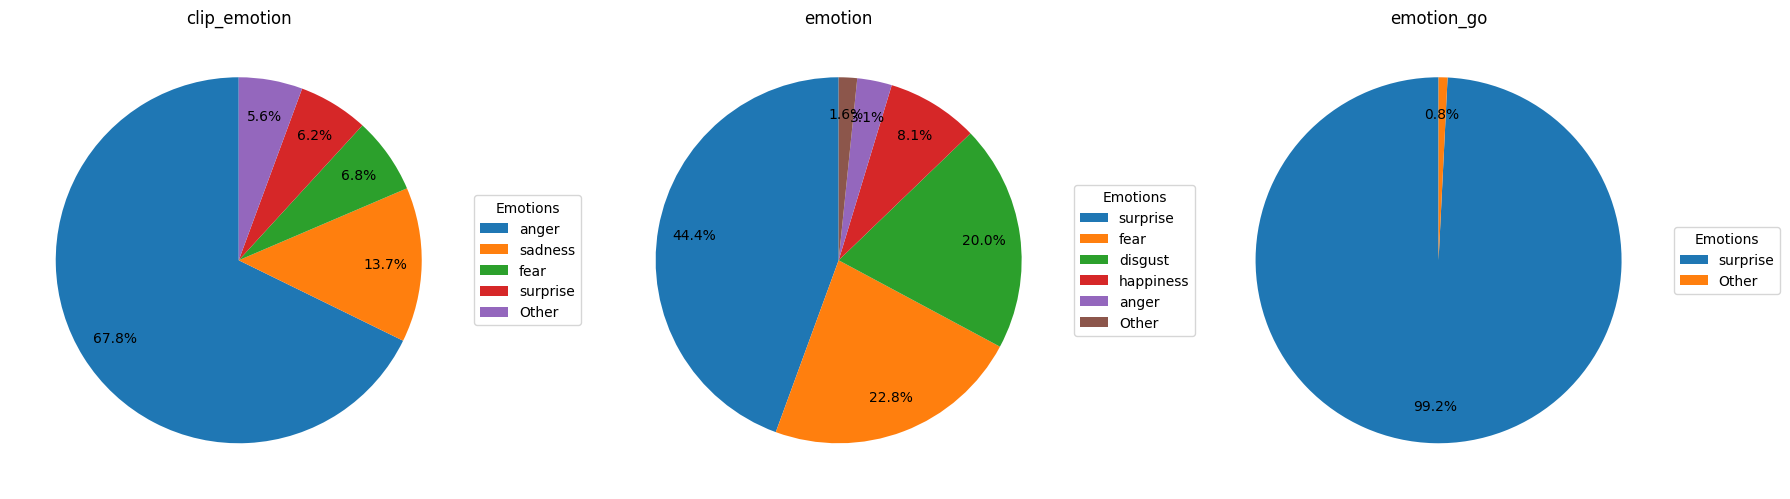

In [86]:
import matplotlib.pyplot as plt

cols = ["clip_emotion", "emotion", "emotion_go"]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, col in enumerate(cols):
    counts = df[col].value_counts()
    
    threshold = 0.03 
    small = counts[counts / counts.sum() < threshold]
    counts = counts[counts / counts.sum() >= threshold]
    if len(small) > 0:
        counts["Other"] = small.sum()

    wedges, texts, autotexts = axes[i].pie(
        counts,
        autopct='%1.1f%%',
        startangle=90,
        pctdistance=0.8, 
        labeldistance=1.1  
    )

    for t in texts:
        t.set_text("")

    axes[i].set_title(col)

    axes[i].legend(
        wedges,
        counts.index,
        title="Emotions",
        loc="center left",
        bbox_to_anchor=(1, 0.5)
    )

plt.tight_layout()
plt.show()

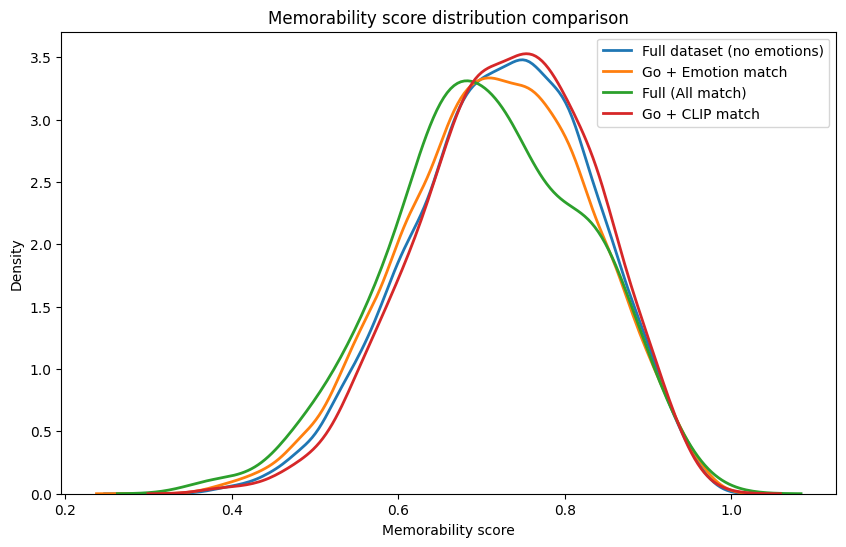

In [89]:
import matplotlib.pyplot as plt
import seaborn as sns

df_all = df.copy()

df_go_match = df[df["emotion_go"] == df["emotion"]]

df_clip_match = df[df["clip_emotion"] == df["emotion"]]


df_full_match = df[
    (df["emotion_go"] == df["emotion"]) &
    (df["clip_emotion"] == df["emotion"])
]

plt.figure(figsize=(10,6))

sns.kdeplot(df_all["memscore"], label="Full dataset (no emotions)", linewidth=2)
sns.kdeplot(df_go_match["memscore"], label="Go + Emotion match", linewidth=2)
sns.kdeplot(df_full_match["memscore"], label="Full (All match)", linewidth=2)
sns.kdeplot(df_clip_match["memscore"], label="Go + CLIP match", linewidth=2)

plt.title("Memorability score distribution comparison")
plt.xlabel("Memorability score")
plt.ylabel("Density")

plt.legend()
plt.show()

In [55]:
df[df.emotion_go == df.emotion].emotion.value_counts()

emotion
surprise     7446
happiness      30
sadness        12
disgust         8
anger           6
fear            4
Name: count, dtype: int64

In [53]:
df.groupby("emotion")["emotion_go"].value_counts()  

emotion    emotion_go
anger      surprise       493
           sadness         11
           anger            6
           disgust          2
           fear             2
           happiness        1
disgust    surprise      3343
           sadness         14
           disgust          8
           anger            1
           happiness        1
fear       surprise      3815
           fear             4
           sadness          4
           disgust          3
happiness  surprise      1330
           happiness       30
           sadness          3
           anger            2
sadness    surprise       256
           sadness         12
           disgust          2
           anger            1
           fear             1
           happiness        1
surprise   surprise      7446
           sadness          8
           happiness        7
           anger            6
           disgust          2
Name: count, dtype: int64

In [69]:
out_path = f"{ROOT_DIR}/lamem_features_v3/lamem_features_emotions_full.parquet"

In [82]:
# Parquet with full metadata
df.to_parquet(out_path, index=False)
print(f"Parquet saved -> {out_path}  shape: {df.shape}")


Parquet saved -> /home/gabriella/Documents/MemorabilityEmotions/lamem_features_v3/lamem_features_emotions_full.parquet  shape: (16815, 24)


In [83]:
df.columns

Index(['name', 'dataset', 'memscore', 'original_emotion', 'error',
       'emotion_happiness', 'emotion_sadness', 'emotion_fear', 'emotion_anger',
       'emotion_disgust', 'emotion_surprise', 'clip_emotion',
       'clip_emotion_conf', 'caption', 'emotion', 'emotion_go',
       'emotion_bert_happiness', 'emotion_bert_sadness', 'emotion_bert_fear',
       'emotion_bert_anger', 'emotion_bert_disgust', 'emotion_bert_surprise',
       'emotion_bert_entropy', 'emotion_bert_prediction'],
      dtype='object')